<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fa9200;">Testing out Indicators across various Stocks to Validate
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------

# Import Packages

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date, datetime
import os
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.formula.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import yfinance as yf
from scipy.signal import argrelextrema
from collections import defaultdict
import sqlite3
import warnings
warnings.filterwarnings("ignore")
import Indicators
import Measurement

# Grab Data for Ticker

In [2]:
tickers = Indicators.save_sp500_tickers()
ticker = tickers[0]
ticker = 'PBR'
ticker = 'WDC'
events = ['ihs_event','hs_event','fw_event','rw_event']
df = Indicators.get_ticker(ticker,500)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker
0,2022-04-01 09:30:00-04:00,50.130001,50.480000,48.439999,48.500000,480657,0.0,0.0,2022-04-01 09:30:00,WDC
1,2022-04-01 10:30:00-04:00,48.549999,48.660000,48.099998,48.119999,365852,0.0,0.0,2022-04-01 10:30:00,WDC
2,2022-04-01 11:30:00-04:00,48.130001,48.215000,47.619999,47.849998,462954,0.0,0.0,2022-04-01 11:30:00,WDC
3,2022-04-01 12:30:00-04:00,47.840000,47.851002,47.625000,47.775002,536261,0.0,0.0,2022-04-01 12:30:00,WDC
4,2022-04-01 13:30:00-04:00,47.775002,48.220001,47.750000,48.209999,255767,0.0,0.0,2022-04-01 13:30:00,WDC
...,...,...,...,...,...,...,...,...,...,...
3486,2024-03-28 11:30:00-04:00,68.809998,68.889900,68.305000,68.425003,674976,0.0,0.0,2024-03-28 11:30:00,WDC
3487,2024-03-28 12:30:00-04:00,68.430000,68.660004,68.379997,68.389999,507268,0.0,0.0,2024-03-28 12:30:00,WDC
3488,2024-03-28 13:30:00-04:00,68.389999,68.540001,68.239998,68.389999,440148,0.0,0.0,2024-03-28 13:30:00,WDC
3489,2024-03-28 14:30:00-04:00,68.400002,68.690002,68.345001,68.480003,685372,0.0,0.0,2024-03-28 14:30:00,WDC


# Add SMA, Min/Max, Events

In [3]:
SMAs = [5,30,60,90]
smoothing = 10
window = 8

df = Indicators.get_sma(df,SMAs)
minmax = Indicators.get_max_min(df, smoothing, window)
invhs = Indicators.find_IHS(minmax).reset_index(drop=True)
rw = Indicators.find_RW(minmax,.03).reset_index(drop=True)
fw = Indicators.find_FW(minmax,.03).reset_index(drop=True)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,SMA5,SMA30,SMA60,SMA90
0,2022-04-01 09:30:00-04:00,50.130001,50.480000,48.439999,48.500000,480657,0.0,0.0,2022-04-01 09:30:00,WDC,NaN,NaN,NaN,NaN
1,2022-04-01 10:30:00-04:00,48.549999,48.660000,48.099998,48.119999,365852,0.0,0.0,2022-04-01 10:30:00,WDC,NaN,NaN,NaN,NaN
2,2022-04-01 11:30:00-04:00,48.130001,48.215000,47.619999,47.849998,462954,0.0,0.0,2022-04-01 11:30:00,WDC,NaN,NaN,NaN,NaN
3,2022-04-01 12:30:00-04:00,47.840000,47.851002,47.625000,47.775002,536261,0.0,0.0,2022-04-01 12:30:00,WDC,NaN,NaN,NaN,NaN
4,2022-04-01 13:30:00-04:00,47.775002,48.220001,47.750000,48.209999,255767,0.0,0.0,2022-04-01 13:30:00,WDC,48.091000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,2024-03-28 11:30:00-04:00,68.809998,68.889900,68.305000,68.425003,674976,0.0,0.0,2024-03-28 11:30:00,WDC,68.138000,66.479560,63.756668,63.054510
3487,2024-03-28 12:30:00-04:00,68.430000,68.660004,68.379997,68.389999,507268,0.0,0.0,2024-03-28 12:30:00,WDC,68.346001,66.639227,63.900002,63.124899
3488,2024-03-28 13:30:00-04:00,68.389999,68.540001,68.239998,68.389999,440148,0.0,0.0,2024-03-28 13:30:00,WDC,68.490001,66.804223,64.045002,63.194677
3489,2024-03-28 14:30:00-04:00,68.400002,68.690002,68.345001,68.480003,685372,0.0,0.0,2024-03-28 14:30:00,WDC,68.497002,66.944890,64.195502,63.266454


# Plot Data

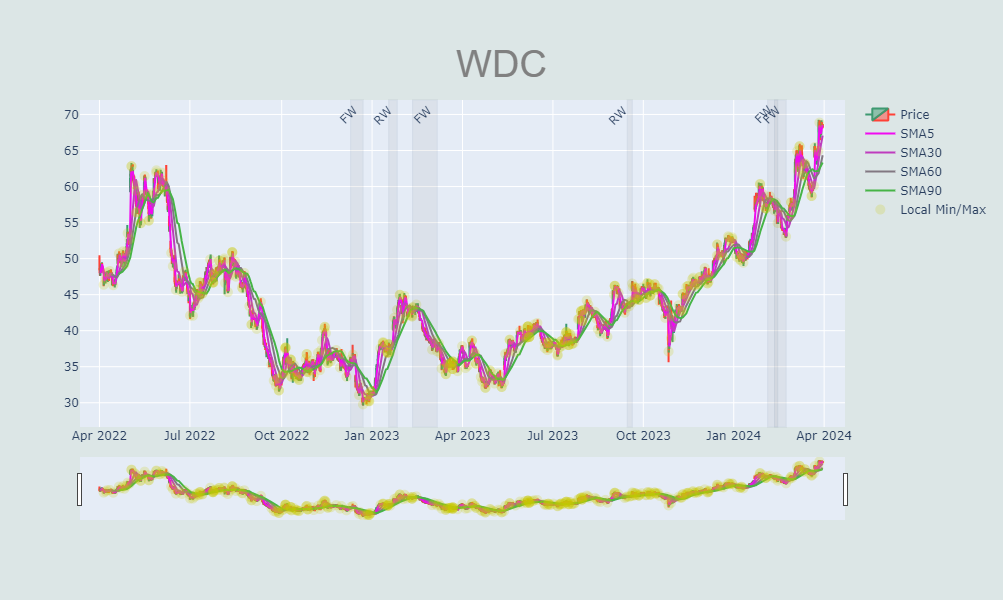

In [4]:
fig = go.Figure()
fig = go.Figure(data=[go.Candlestick(x=df['date'],
                open=df['open'],
                high=df['high'],
                low=df['low'],
                close=df['close'],
                name='Price')])
for n in SMAs:
    rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
    fig.add_trace(go.Scatter(x=df['date'],
                y=df['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
fig.add_trace(go.Scatter(x=minmax['date'],
                y=minmax['close'],
                mode='markers',
                name='Local Min/Max',
                marker=dict(color='rgb(200,200,0)',
                            size=10,
                            opacity=0.2)
                        ))
# iterate through the shaded regions dataframe

for index, row in invhs.iterrows():
    
    # retrieve the dates
    start = row['start_event']
    end = row['end_event']

    # add shaded region
    fig.add_vrect(
            x0=start,
            x1=end,
            fillcolor="grey",
            opacity=0.1,
            line_width=1,
            annotation_text='IHS',
            annotation_textangle=-45
        )   
# iterate through the shaded regions dataframe
for index, row in fw.iterrows():
    
    # retrieve the dates
    start = row['start_event']
    end = row['end_event']

    # add shaded region
    fig.add_vrect(
            x0=start,
            x1=end,
            fillcolor="grey",
            opacity=0.1,
            line_width=1,
            annotation_text='FW',
            annotation_textangle=-45
        )  
for index, row in rw.iterrows():
    
    # retrieve the dates
    start = row['start_event']
    end = row['end_event']

    # add shaded region
    fig.add_vrect(
            x0=start,
            x1=end,
            fillcolor="grey",
            opacity=0.1,
            line_width=1,
            annotation_text='RW',
            annotation_textangle=-45
        )  
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
        ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

# Zoom in on Specific Event

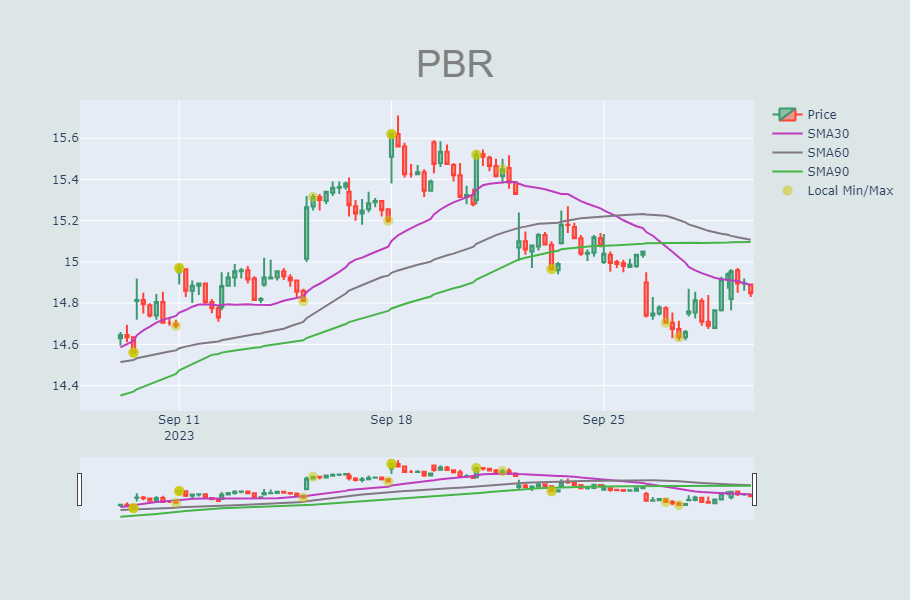

In [46]:
df2 = Indicators.main(ticker,500,SMAs,smoothing,window)
eventType = 'rw_event'
ID = list(df2[df2.date==df2[df2[eventType]==1].date.min()].index)[0]
chartdf = df2.iloc[ID-10:ID+95].copy()
minmax2 = minmax[(minmax.date>=chartdf.date.min())&(minmax.date<=chartdf.date.max())].copy()
fig = go.Figure()
fig = go.Figure(data=[go.Candlestick(x=chartdf['date'],
                open=chartdf['open'],
                high=chartdf['high'],
                low=chartdf['low'],
                close=chartdf['close'],
                name='Price')])
for n in SMAs:
    rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
    fig.add_trace(go.Scatter(x=chartdf['date'],
                y=chartdf['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
fig.add_trace(go.Scatter(x=minmax2['date'],
                y=minmax2['close'],
                mode='markers',
                name='Local Min/Max',
                marker=dict(color='rgb(200,200,0)',
                            size=10,
                            opacity=0.5)
                        ))
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
        ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

# Build Inidcators and Group by Change During Event

In [5]:
M = 80
K = 500
window = 5
smoothing = 5
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}


df3 = Measurement.combine_events(tickers,events,SMAs,smoothing,window,M,K)
df3.reset_index(inplace=True,drop=True)
#df3['date'] = pd.to_datetime(df.datetime, errors='coerce').dt.tz_localize(None)
df3.groupby([x for x in df3.columns if '_event' in x]).lower_chng.mean().reset_index()

BRK.B: No data found, symbol may be delisted
'DataFrame' object has no attribute 'Datetime'
BF.B: Period '500d' is invalid, must be one of ['1mo', '3mo', '6mo', 'ytd', '1y', '2y', '5y', '10y', 'max']
'DataFrame' object has no attribute 'Datetime'


,fw_event,rw_event,ihs_event,hs_event,lower_chng
0,-2,-1,-1,-1,-0.006887
1,-2,-1,-1,0,-0.019178
2,-2,-1,-1,1,-0.006558
3,-2,-1,0,-1,-0.011572
4,-2,-1,0,0,-0.028149
...,...,...,...,...,...
177,1,1,0,0,-0.053989
178,1,1,0,1,-0.030860
179,1,1,1,-1,-0.036651
180,1,1,1,0,-0.067192


In [14]:
event = 'fw_event'
#event_start = re.sub('_event','',[key for key, val in events.items() if event in key][0]) + '_start_time'
#event_end = re.sub('_event','',[key for key, val in events.items() if event in key][0]) + '_end_time'
df3[event + '_group'] = np.where(df3[event].shift(1) != df3[event],1,0)
df3[event + '_group'] = df3.groupby(['ticker'])[event + '_group'].cumsum()
df3[event + '_start_time'] = df3.groupby(['ticker',event + '_group'])['date'].transform('min')
df3[event + '_end_time'] = df3.groupby(['ticker',event + '_group'])['date'].transform('max')
df3.groupby(['ticker',event + '_start_time',event + '_end_time']).agg({'volume':'size',event:'mean'}).reset_index().head(20)

,ticker,fw_event_start_time,fw_event_end_time,volume,fw_event
0,A,2022-04-01 09:30:00,2022-06-02 14:30:00,300,0.0
1,A,2022-06-02 15:30:00,2022-06-09 13:30:00,34,1.0
2,A,2022-06-09 14:30:00,2022-06-27 15:30:00,79,-1.0
3,A,2022-06-28 09:30:00,2022-06-28 09:30:00,1,-2.0
4,A,2022-06-28 10:30:00,2023-02-14 10:30:00,1111,0.0
5,A,2023-02-14 11:30:00,2023-02-17 10:30:00,27,1.0
6,A,2023-02-17 11:30:00,2023-03-07 12:30:00,79,-1.0
7,A,2023-03-07 13:30:00,2023-03-07 13:30:00,1,-2.0
8,A,2023-03-07 14:30:00,2023-04-19 09:30:00,206,0.0
9,A,2023-04-19 10:30:00,2023-04-25 14:30:00,33,1.0


In [18]:
#event = 'rw_event'
#pd.options.display.float_format = '{:.2%}'.format
def get_totals(df3, weight=0.015):

    final4 = pd.DataFrame()
    for event in events:
        df3[event + '_group'] = np.where(df3[event].shift(1) != df3[event],1,0)
        df3[event + '_group'] = df3.groupby(['ticker'])[event + '_group'].cumsum()
        df3[event + '_start_time'] = df3.groupby(['ticker',event + '_group'])['date'].transform('min')
        df3[event + '_end_time'] = df3.groupby(['ticker',event + '_group'])['date'].transform('max')
        if [val for key, val in events.items() if event in key][0] == 'bull':
            final = df3.groupby(['ticker',event, event + '_start_time',event + '_end_time']).upper_chng.describe().reset_index()
        else:
            final = df3.groupby(['ticker',event, event + '_start_time',event + '_end_time']).lower_chng.describe().reset_index()

        final2 = pd.pivot_table(final[(final.ticker.isin(final[final[event].isin([-2])].ticker))&(final[event].isin([-2,0]))],
               values = ['count','50%'], 
               index = ['ticker',event + '_start_time',event + '_end_time'],
               columns = [event],
               aggfunc = 'mean'
              )
        final2.columns = [str(x) + str(y) for x,y in final2.columns]
        #final2 = final2.merge(max_date, on = 'ticker')
        if [val for key, val in events.items() if event in key][0] == 'bull':
            final2['Indicator'] = np.where(final2['50%-2'] > final2['50%0'], 1, 0)
        else:
            final2['Indicator'] = np.where(final2['50%-2'] < final2['50%0'], 1, 0)
    
        final3 = final2[abs(final2['50%-2']-final2['50%0']) > weight].copy()
        final3['event'] = event
    
        final4 = pd.concat([final3,final4])
        
    return final4

final4 = get_totals(df3,0.02)
final4.reset_index(inplace=True)
final4['50%-2'] = pd.Series(["{0:.2f}%".format(val * 100) for val in final4['50%-2']], index = final4.index)
final4['50%0'] = pd.Series(["{0:.2f}%".format(val * 100) for val in final4['50%0']], index = final4.index)
#eventSuccess = sum(final4['Indicator']*final4['count-2'])/final4['count-2'].sum()
eventSuccess = final4[['Indicator','count-2','event']].copy()
eventSuccess['Indicator'] = eventSuccess['Indicator']*eventSuccess['count-2']
eventSuccess = eventSuccess.groupby(['event']).sum()
eventSuccess['per_success'] = eventSuccess['Indicator']/eventSuccess['count-2']
eventSuccess['per_success'] = pd.Series(["{0:.2f}%".format(val * 100) for val in eventSuccess['per_success']], index = eventSuccess.index)
print('Percentage of Success: {}'.format(eventSuccess))
#print(final4.date.min())
final4

Percentage of Success: Empty DataFrame
Columns: [Indicator, count-2, per_success]
Index: []


,ticker,rw_event_start_time,rw_event_end_time,50%-2,50%0,count-2,count0,Indicator,event


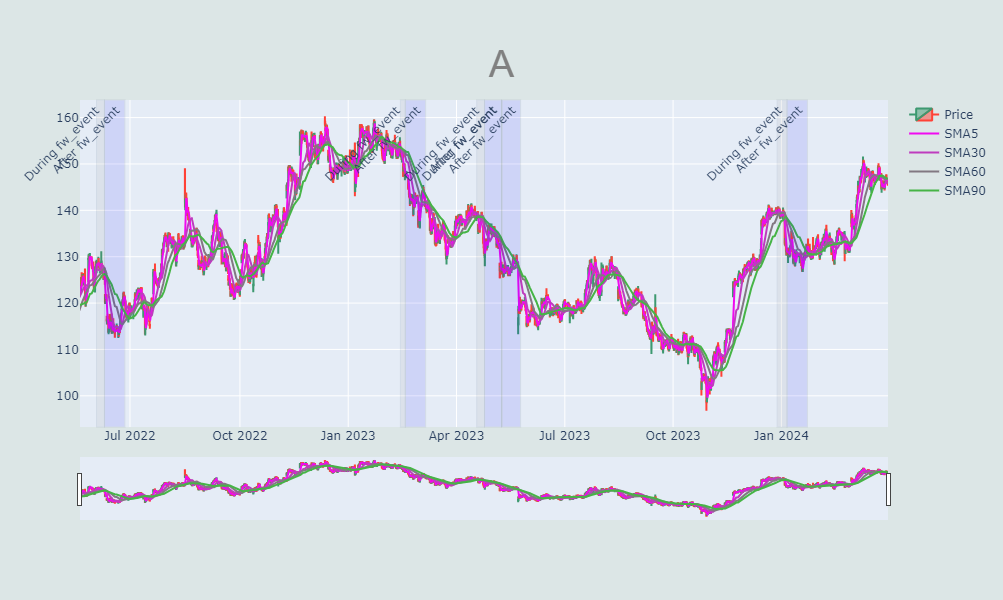

In [17]:
#event = 'rw_event'
ticker = 'A'
#ticker = final4[final4.Indicator==1].ticker.sample(1).tolist()
#ticker = ticker[0]
df = df3[df3.ticker==ticker].copy()
df[event+'_ranges'] = np.where(df[event] != df[event].shift(1), 1, 0)
df[event+'_ranges'] = df[event+'_ranges'].cumsum()
df[event+'_start'] = df.groupby([event+'_ranges'])['datetime'].transform('min')
df[event+'_end'] = df.groupby([event+'_ranges'])['datetime'].transform('max')
fig = go.Figure()
fig = go.Figure(data=[go.Candlestick(x=df['date'],
                open=df['open'],
                high=df['high'],
                low=df['low'],
                close=df['close'],
                name='Price')])
for n in SMAs:
    rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
    fig.add_trace(go.Scatter(x=df['date'],
                y=df['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
    
# iterate through the shaded regions dataframe
rw = df.groupby([event+'_start',event+'_end'])[event].mean().reset_index()
rw = rw[rw[event].isin([1,-1])].reset_index(drop=True)
eventName = {1:'During {}'.format(event),-1:'After {}'.format(event),0:'No {}'.format(event)}
eventList = list(rw[event])
eventList = [eventName.get(item,item)  for item in eventList]
for index, row in rw.iterrows():
    eventValue = eventList[index]
    # retrieve the dates
    if re.match('During .*',eventValue):
        fcolor = "grey"
    else:
        fcolor = "blue"
    start = row[event+'_start']
    end = row[event+'_end']
    # add shaded region
    fig.add_vrect(
            x0=start,
            x1=end,
            fillcolor=fcolor,
            opacity=0.1,
            line_width=1,
            annotation_text=eventValue,
            annotation_textangle=-45
        )  
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
        ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

In [22]:
weight = 0.02
final4 = pd.DataFrame()
for event in events:
        df3[event + '_group'] = np.where(df3[event].shift(1) != df3[event],1,0)
        df3[event + '_group'] = df3.groupby(['ticker'])[event + '_group'].cumsum()
        df3[event + '_start_time'] = df3.groupby(['ticker',event + '_group'])['date'].transform('min')
        df3[event + '_end_time'] = df3.groupby(['ticker',event + '_group'])['date'].transform('max')
        if [val for key, val in events.items() if event in key][0] == 'bull':
            final = df3.groupby(['ticker',event, event + '_start_time',event + '_end_time']).upper_chng.describe().reset_index()
        else:
            final = df3.groupby(['ticker',event, event + '_start_time',event + '_end_time']).lower_chng.describe().reset_index()

        final2 = pd.pivot_table(final[(final.ticker.isin(final[final[event].isin([-2])].ticker))&(final[event].isin([-2,0]))],
               values = ['count','50%'], 
               index = ['ticker',event + '_start_time',event + '_end_time'],
               columns = [event],
               aggfunc = 'mean'
              )
        final2.columns = [str(x) + str(y) for x,y in final2.columns]
        final2['50%0'] = final2['50%0'].shift(1)
        final2['count0'] = final2['count0'].shift(1)
        if [val for key, val in events.items() if event in key][0] == 'bull':
            final2['Indicator'] = np.where(final2['50%-2'] > final2['50%0'], 1, 0)
        else:
            final2['Indicator'] = np.where(final2['50%-2'] < final2['50%0'], 1, 0)
    
        final3 = final2[abs(final2['50%-2']-final2['50%0']) > weight].copy()
        final3['event'] = event
    
        final4 = pd.concat([final3,final4])
final4

50%-2      50%0  count-2  \
ticker rw_event_start_time rw_event_end_time                                  
A      2023-09-19 12:30:00 2023-09-19 12:30:00 -0.124465 -0.043156      1.0   
AAL    2022-09-01 09:30:00 2022-09-01 09:30:00 -0.244872 -0.102017      1.0   
       2024-01-03 11:30:00 2024-01-03 11:30:00 -0.132438 -0.073309      1.0   
AAPL   2022-11-14 15:30:00 2022-11-14 15:30:00 -0.150502 -0.069860      1.0   
       2023-02-02 12:30:00 2023-02-02 12:30:00 -0.028089 -0.071244      1.0   
...                                                  ...       ...      ...   
ZBRA   2023-01-11 12:30:00 2023-01-11 12:30:00  0.158879  0.057635      1.0   
ZTS    2022-08-29 10:30:00 2022-08-29 10:30:00  0.019743  0.045498      1.0   
       2023-01-18 15:30:00 2023-01-18 15:30:00  0.108329  0.037133      1.0   
       2023-03-24 15:30:00 2023-03-24 15:30:00  0.000248  0.119077      1.0   
       2024-02-08 11:30:00 2024-02-08 11:30:00  0.050355  0.026791      1.0   

                                                count0  Indicator      event  
ticker rw_event_start_time rw_event_end_time                                  
A      2023-09-19 12:30:00 2023-09-19 12:30:00  1432.0          1   rw_event  
AAL    2022-09-01 09:30:00 2022-09-01 09:30:00   410.0          1   rw_event  
       2024-01-03 11:30:00 2024-01-03 11:30:00   766.0          1   rw_event  
AAPL   2022-11-14 15:30:00 2022-11-14 15:30:00   883.0          1   rw_event  
       2023-02-02 12:30:00 2023-02-02 12:30:00   272.0          0   rw_event  
...                                                ...        ...        ...  
ZBRA   2023-01-11 12:30:00 2023-01-11 12:30:00   965.0          1  ihs_event  
ZTS    2022-08-29 10:30:00 2022-08-29 10:30:00   216.0          0  ihs_event  
       2023-01-18 15:30:00 2023-01-18 15:30:00   577.0          1  ihs_event  
       2023-03-24 15:30:00 2023-03-24 15:30:00   166.0          0  ihs_event  
       2024-02-08 11:30:00 2024-02-08 11:30:00   566.0          1  ihs_event  

[6588 rows x 6 columns]

In [27]:
#final4.reset_index(inplace=True)
final4[final4.ticker=='A'].groupby('event')['Indicator'].mean()

event
fw_event     0.333333
hs_event     0.500000
ihs_event    0.714286
rw_event     1.000000
Name: Indicator, dtype: float64

In [28]:
final4[final4['event']=='fw_event']

,level_0,index,ticker,rw_event_start_time,rw_event_end_time,50%-2,50%0,count-2,count0,Indicator,event
1643,1643,1643,A,2022-06-28 09:30:00,2022-06-28 09:30:00,-0.000374,0.041335,1.0,220.0,0,fw_event
1644,1644,1644,A,2023-03-07 13:30:00,2023-03-07 13:30:00,0.008933,0.059722,1.0,1111.0,0,fw_event
1645,1645,1645,A,2023-05-10 09:30:00,2023-05-10 09:30:00,0.053263,0.026386,1.0,206.0,1,fw_event
1646,1646,1646,AAL,2023-08-17 12:30:00,2023-08-17 12:30:00,0.024389,0.067955,1.0,986.0,0,fw_event
1647,1647,1647,AAL,2023-11-07 10:30:00,2023-11-07 10:30:00,0.089164,0.015452,1.0,285.0,1,fw_event
...,...,...,...,...,...,...,...,...,...,...,...
3083,3083,3083,ZBRA,2023-07-11 09:30:00,2023-07-11 09:30:00,0.147371,0.050246,1.0,191.0,1,fw_event
3084,3084,3084,ZBRA,2023-09-25 13:30:00,2023-09-25 13:30:00,0.000798,0.049285,1.0,282.0,0,fw_event
3085,3085,3085,ZBRA,2024-01-31 14:30:00,2024-01-31 14:30:00,0.080952,0.057251,1.0,510.0,1,fw_event
3086,3086,3086,ZTS,2023-07-21 13:30:00,2023-07-21 13:30:00,0.091582,0.035430,1.0,528.0,1,fw_event
